# Experiment 8: Fuzzy Washing Machine Controller
**Name:** Arshan Attar  
**Roll Number:** 231408  

In [ ]:
!pip install -U scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.4 MB/s eta 0:00:00


## 1. Inputs and Output Setup

In [ ]:
from skfuzzy import control as ctrl
import skfuzzy as fuzz
import numpy as np
import matplotlib.pyplot as plt

class washing_machine:
    type_grease = ctrl.Antecedent(np.arange(0, 101, 1), 'type_grease')
    type_dirt = ctrl.Antecedent(np.arange(0, 101, 1), 'type_dirt')
    wash_time = ctrl.Consequent(np.arange(0, 61, 1), 'wash_time')

    degree_names = ['Low', 'Medium', 'High']
    type_names = ['Nonfat', 'Medium', 'Fat']

    # Populating them into auto membership functions
    type_grease.automf(names=degree_names)
    type_dirt.automf(names=type_names)

    # Washing Time Universe
    wash_time['Veryshort'] = fuzz.trimf(wash_time.universe, [0, 0, 12])
    wash_time['Short'] = fuzz.trimf(wash_time.universe, [0, 12, 24])
    wash_time['Medium'] = fuzz.trimf(wash_time.universe, [12, 24, 40])
    wash_time['Long'] = fuzz.trimf(wash_time.universe, [20, 40, 60])
    wash_time['Verylong'] = fuzz.trimf(wash_time.universe, [35, 48, 60])

    # Rule Application (Initial OR logic - will be updated by Cell 3)
    rule1 = ctrl.Rule(type_grease['High'] | type_dirt['Fat'], wash_time['Verylong'])
    rule2 = ctrl.Rule(type_grease['Medium'] | type_dirt['Fat'], wash_time['Long'])
    rule3 = ctrl.Rule(type_grease['Low'] | type_dirt['Fat'], wash_time['Long'])
    rule4 = ctrl.Rule(type_grease['High'] | type_dirt['Medium'], wash_time['Long'])
    rule5 = ctrl.Rule(type_grease['Medium'] | type_dirt['Medium'], wash_time['Medium'])
    rule6 = ctrl.Rule(type_grease['Low'] | type_dirt['Medium'], wash_time['Medium'])
    rule7 = ctrl.Rule(type_grease['High'] | type_dirt['Nonfat'], wash_time['Medium'])
    rule8 = ctrl.Rule(type_grease['Medium'] | type_dirt['Nonfat'], wash_time['Short'])
    rule9 = ctrl.Rule(type_grease['Low'] | type_dirt['Nonfat'], wash_time['Veryshort'])

    # Washing Control Simulation
    washing_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
    washing = ctrl.ControlSystemSimulation(washing_ctrl)

def fuzzify_laundry(fuzz_type, fuzz_degree):
    washing_machine.washing.input['type_dirt'] = fuzz_type
    washing_machine.washing.input['type_grease'] = fuzz_degree

    washing_machine.washing.compute()

    # Generate the diagram
    washing_machine.wash_time.view(sim=washing_machine.washing)
    plt.show() # This is required to actually display the diagram on your screen!

    return washing_machine.washing.output['wash_time']

## 2. Membership Functions

Enter Type of Dirtiness [0-100]: 60
Enter Type of Grease [0-100]: 70
Calculated Wash Time: 29.97 minutes


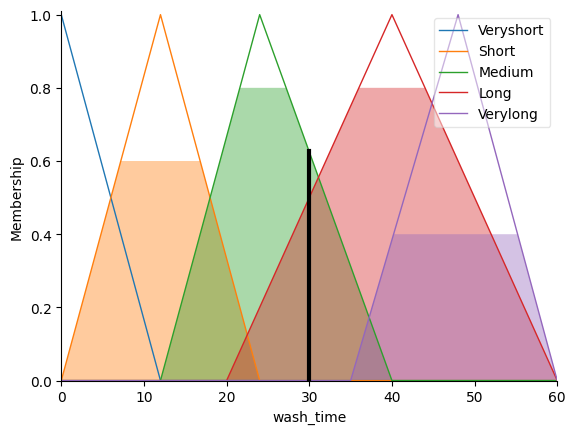

In [ ]:
def compute_washing_parameters(type_of_dirt, degree_of_dirt):
    if type_of_dirt < 0.0 or type_of_dirt > 100.0:
        raise Exception("Invalid Type of Dirtiness: %f" % type_of_dirt)
    if degree_of_dirt < 0.0 or degree_of_dirt > 100.0:
        raise Exception("Invalid Degree of Dirtiness: %f" % degree_of_dirt)

    type_fuzzy = fuzzify_laundry(type_of_dirt, degree_of_dirt)
    return type_fuzzy

if __name__ == '__main__':
    type_of_dirt = float(input("Enter Type of Dirtiness [0-100]: "))
    degree_of_dirt = float(input("Enter Type of Grease [0-100]: "))
    print(f"Calculated Wash Time: {washing_parameters:.2f} minutes")

    washing_parameters = compute_washing_parameters(type_of_dirt, degree_of_dirt)

## 3. Rules

In [ ]:
# Corrected Rule Application
# Mapping: SD=Nonfat, MD=Medium, LD=Fat  |  SG=Low, MG=Medium, LG=High

rule1 = ctrl.Rule(washing_machine.type_dirt['Nonfat'] & washing_machine.type_grease['Low'], washing_machine.wash_time['Veryshort'])
rule2 = ctrl.Rule(washing_machine.type_dirt['Nonfat'] & washing_machine.type_grease['Medium'], washing_machine.wash_time['Medium'])
rule3 = ctrl.Rule(washing_machine.type_dirt['Nonfat'] & washing_machine.type_grease['High'], washing_machine.wash_time['Long'])

rule4 = ctrl.Rule(washing_machine.type_dirt['Medium'] & washing_machine.type_grease['Low'], washing_machine.wash_time['Short'])
rule5 = ctrl.Rule(washing_machine.type_dirt['Medium'] & washing_machine.type_grease['Medium'], washing_machine.wash_time['Medium'])
rule6 = ctrl.Rule(washing_machine.type_dirt['Medium'] & washing_machine.type_grease['High'], washing_machine.wash_time['Long'])

rule7 = ctrl.Rule(washing_machine.type_dirt['Fat'] & washing_machine.type_grease['Low'], washing_machine.wash_time['Medium'])
rule8 = ctrl.Rule(washing_machine.type_dirt['Fat'] & washing_machine.type_grease['Medium'], washing_machine.wash_time['Long'])
rule9 = ctrl.Rule(washing_machine.type_dirt['Fat'] & washing_machine.type_grease['High'], washing_machine.wash_time['Verylong'])

# We must recompile the control system here so it uses these new rules!
washing_machine.washing_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
washing_machine.washing = ctrl.ControlSystemSimulation(washing_machine.washing_ctrl)

print("Rules updated successfully!")

Rules updated successfully!
